#regression for classification


Data: two classes of randome points

In [1]:
import keras
import numpy as np

In [13]:
num_samples=1000
negative_samples= np.random.multivariate_normal(mean=[0,3], cov=[[1,0.5],[0.5,1]], size=num_samples)
positive_samples= np.random.multivariate_normal(mean=[3,0], cov=[[1,0.5],[0.5,1]], size=num_samples)

In [14]:
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)
inputs.shape

(2000, 2)

In [21]:
targets = np.vstack((np.zeros((num_samples,1),dtype="float32"),
                    np.ones((num_samples,1),dtype="float32")))
targets.shape

(2000, 1)

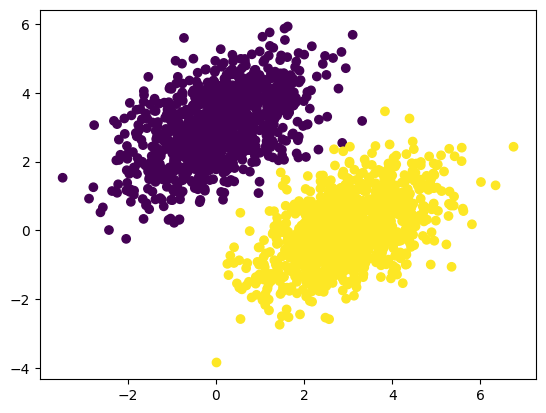

In [24]:
import matplotlib.pyplot as plt
plt.scatter(inputs[:,0],inputs[:,1],c=targets)
plt.show()

creating linear classifer variables

In [26]:
import tensorflow as tf

In [29]:
input_dim=2
output_dim = 1
W = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim,output_dim)))
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim,)))

forward pass

In [30]:
def model(inputs):
  return tf.matmul(inputs,W)+b

mse loss function

In [31]:
def mse_loss(targets, predictions):
  per_sample_losses = tf.square(targets-predictions)
  return tf.reduce_mean(per_sample_losses)

train step

In [35]:
learning_rate = 0.1
def train_step(inputs, targets):
  with tf.GradientTape() as tape:
    predictions = model(inputs)
    loss= mse_loss(targets, predictions)
  grad_loss_wrt_W,grad_loss_wrt_b = tape.gradient(loss, [W,b])
  W.assign_sub(grad_loss_wrt_W*learning_rate)
  b.assign_sub(grad_loss_wrt_b*learning_rate)
  return loss

batch traning loop

In [36]:
for step in range(40):
  loss = train_step(inputs, targets)
  print(f"Loss at step {step}: {loss}")

Loss at step 0: 6.77837610244751
Loss at step 1: 1.1121009588241577
Loss at step 2: 0.3044874966144562
Loss at step 3: 0.17970490455627441
Loss at step 4: 0.15203814208507538
Loss at step 5: 0.13893266022205353
Loss at step 6: 0.12868677079677582
Loss at step 7: 0.11958174407482147
Loss at step 8: 0.1113106980919838
Loss at step 9: 0.10377124696969986
Loss at step 10: 0.0968950167298317
Loss at step 11: 0.0906231552362442
Loss at step 12: 0.08490244299173355
Loss at step 13: 0.07968446612358093
Loss at step 14: 0.0749250203371048
Loss at step 15: 0.07058382779359818
Loss at step 16: 0.06662411242723465
Loss at step 17: 0.06301239132881165
Loss at step 18: 0.05971803888678551
Loss at step 19: 0.05671318992972374
Loss at step 20: 0.05397239699959755
Loss at step 21: 0.05147245526313782
Loss at step 22: 0.04919220879673958
Loss at step 23: 0.04711233451962471
Loss at step 24: 0.045215241611003876
Loss at step 25: 0.04348485544323921
Loss at step 26: 0.041906531900167465
Loss at step 27: 0

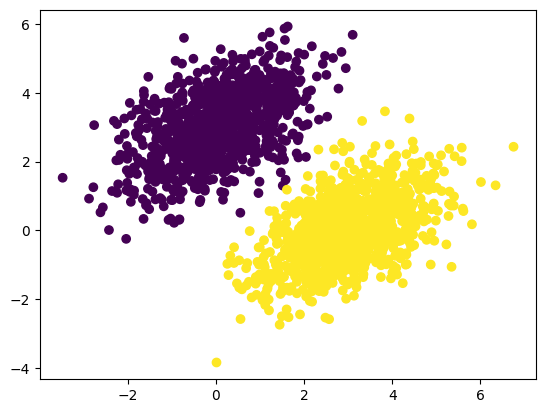

In [39]:
predictions = model(inputs)
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)
plt.show()

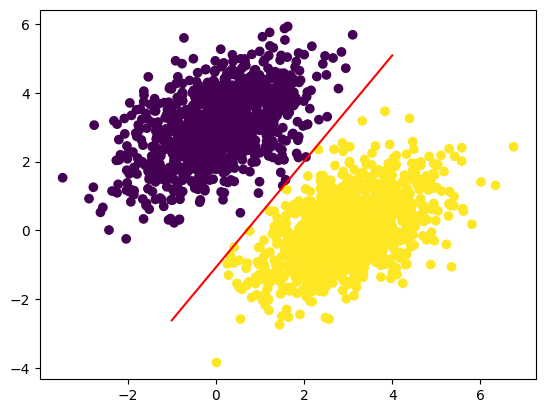

In [43]:
x=np.linspace(-1,4,100)
y=-W[0]/W[1]*x+(0.5-b)/W[1]
plt.plot(x,y,"-r")
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)
plt.show()